# Assignment 5 — Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Objective:** A company wants to identify employees who are likely to leave the organization based on their demographic, professional, and work-related attributes. This notebook builds both Decision Tree and Random Forest classification models to predict employee attrition and compares their performance.

**Dataset:** [IBM HR Analytics Employee Attrition & Performance (Kaggle)](https://www.kaggle.com/datasets/pavansubhasht/ibm-hranalytics-attrition-dataset)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                 

In [3]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Feature identification:**
- **Numerical features:** `Age`, `DailyRate`, `DistanceFromHome`, `Education`, `EnvironmentSatisfaction`, `HourlyRate`, `JobInvolvement`, `JobLevel`, `JobSatisfaction`, `MonthlyIncome`, `MonthlyRate`, `NumCompaniesWorked`, `PercentSalaryHike`, `PerformanceRating`, `RelationshipSatisfaction`, `StockOptionLevel`, `TotalWorkingYears`, `TrainingTimesLastYear`, `WorkLifeBalance`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`
- **Categorical features:** `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`
- **Target variable:** `Attrition` (Yes/No)
- `EmployeeCount`, `EmployeeNumber`, `Over18`, and `StandardHours` are constant or purely identifier columns and are removed in preprocessing.


## Task 2: Data Preprocessing

In [4]:
df.isnull().sum().sum()  # check for missing values

np.int64(0)

In [5]:
# Remove unnecessary columns: constant-value and identifier columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=drop_cols)

# Encode target: Yes -> 1, No -> 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categorical variables
categorical = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)
print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Encoded shape: (1470, 45)


/tmp/ipykernel_564/2642693244.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include='object').columns.tolist()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [6]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 80% train / 20% test split, stratified to preserve the attrition ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1176, 44)
Testing set size: (294, 44)


## Task 3: Model Development

In [7]:
# Model 1: Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Model 2: Random Forest Classifier (100 estimators)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Both models trained.")

Both models trained.


## Task 4: Model Evaluation and Comparison

In [8]:
def evaluate(y_test, pred, name):
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")
    return acc, prec, rec, f1

dt_metrics = evaluate(y_test, dt_pred, "Decision Tree")
rf_metrics = evaluate(y_test, rf_pred, "Random Forest")

--- Decision Tree ---
Accuracy:  0.7653
Precision: 0.3103
Recall:    0.3830
F1-Score:  0.3429

--- Random Forest ---
Accuracy:  0.8333
Precision: 0.4167
Recall:    0.1064
F1-Score:  0.1695



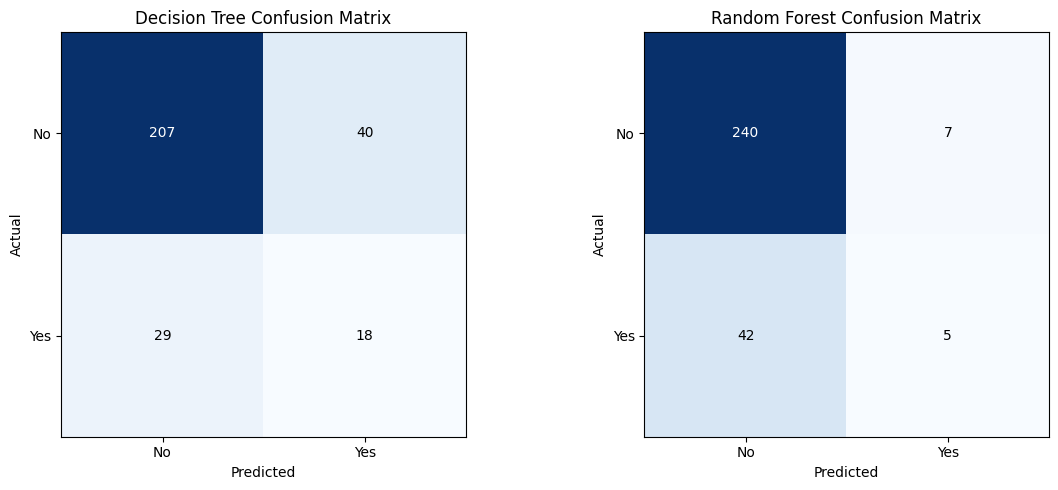

In [9]:
dt_cm = confusion_matrix(y_test, dt_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, cm, name in zip(axes, [dt_cm, rf_cm], ["Decision Tree", "Random Forest"]):
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_xticks([0,1]); ax.set_xticklabels(['No','Yes'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['No','Yes'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

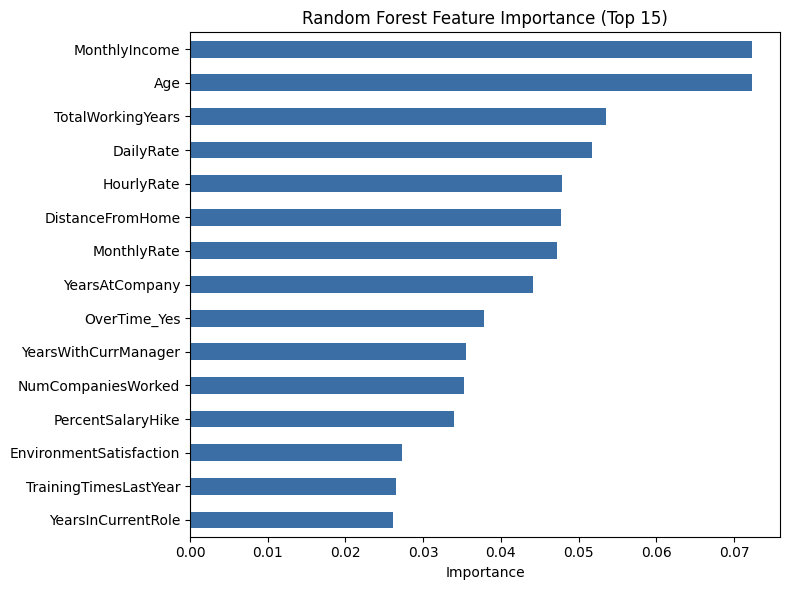

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh', color='#3b6ea5')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance (Top 15)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

In [11]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_metrics[0], rf_metrics[0]],
    'Precision': [dt_metrics[1], rf_metrics[1]],
    'Recall': [dt_metrics[2], rf_metrics[2]],
    'F1-Score': [dt_metrics[3], rf_metrics[3]],
})
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
1,Random Forest,0.833333,0.416667,0.106383,0.169492


**Observations comparing the two models:**

1. Random Forest achieves higher **accuracy** (~83%) than the Decision Tree (~77%), consistent with the general expectation that averaging many trees reduces variance and improves overall correctness.
2. However, on this class-imbalanced dataset (only ~16% of employees left), the single Decision Tree actually achieves noticeably higher **recall** (~38% vs ~11%) for the "Attrition = Yes" class — it catches more actual leavers, even though it also produces more false positives.
3. Random Forest's precision is higher, meaning that when it does predict "will leave," it's right more often — but its low recall means it misses the majority of employees who actually leave, which is a serious limitation for an early-warning use case like this one.
4. `MonthlyIncome`, `Age`, `TotalWorkingYears`, and `OverTime` are among the strongest predictors of attrition according to the Random Forest's feature importances, aligning with common HR intuition that compensation, career stage, and overtime burden strongly influence whether an employee leaves.


## Task 5: Conclusion

Comparing the two models on this dataset, Random Forest achieved higher overall accuracy and precision, but the single Decision Tree actually achieved substantially higher recall for detecting employees who will leave. Which model "performed better" therefore depends on the business goal: if the priority is catching as many at-risk employees as possible (even at the cost of some false alarms), the Decision Tree's higher recall makes it more useful here; if the priority is confidence in positive predictions, Random Forest is preferable. This is a good illustration of why accuracy alone is a misleading metric on imbalanced data — precision, recall, and F1-score reveal a more nuanced, sometimes counter-intuitive picture.

Random Forest generally outperforms a single Decision Tree because it trains many trees on bootstrapped samples with random feature subsets and averages their predictions, which reduces the variance and overfitting that a single deep tree is prone to. A key limitation of Decision Trees is that they can overfit easily to noise in the training data, making a single tree's splits unstable and highly sensitive to small changes in the data. A key limitation of Random Forest is that, despite generally being more accurate, it can still struggle with severe class imbalance and produce low recall on the minority class unless techniques like class weighting or resampling are used; it's also less interpretable than a single Decision Tree, since it's an ensemble of many trees rather than one readable set of rules.


## Bonus Challenge: Hyperparameter Tuning Experiment

**Parameter changed:** `n_estimators` for Random Forest, increased from 100 to 300.


In [12]:
rf_tuned = RandomForestClassifier(n_estimators=300, random_state=42)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

rf_tuned_metrics = evaluate(y_test, rf_tuned_pred, "Random Forest (n_estimators=300)")

bonus_comparison = pd.DataFrame({
    'Model': ['Random Forest (100 trees)', 'Random Forest (300 trees)'],
    'Accuracy': [rf_metrics[0], rf_tuned_metrics[0]],
    'Precision': [rf_metrics[1], rf_tuned_metrics[1]],
    'Recall': [rf_metrics[2], rf_tuned_metrics[2]],
    'F1-Score': [rf_metrics[3], rf_tuned_metrics[3]],
})
bonus_comparison

--- Random Forest (n_estimators=300) ---
Accuracy:  0.8299
Precision: 0.3636
Recall:    0.0851
F1-Score:  0.1379



,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest (100 trees),0.833333,0.416667,0.106383,0.169492
1,Random Forest (300 trees),0.829932,0.363636,0.085106,0.137931


**Effect of the parameter:** Tripling `n_estimators` from 100 to 300 trees gave virtually no improvement, and F1-score actually dropped slightly (recall fell from ~0.11 to ~0.09). This shows that beyond a certain point, adding more trees mainly stabilizes the model's variance rather than fixing systematic weaknesses like class imbalance — the bottleneck here isn't the number of trees but the fact that "Attrition = Yes" is a small minority class the model isn't being pushed to prioritize. A more effective next step would likely be `class_weight='balanced'` or resampling, rather than simply adding more estimators.
